The following is my updated simulation of mRNA movements around the mitochondrion, using the differential equations. This creates a matrix of which parts of the graph are changing, then applies the expected change. 

Throughout this code, I refer to mRNA as "particles" for convenience.

I begin by importing the various modules I used or may use here, including the custom modules I created for the directional graph object. This object has two components: "Edges", which is a list of lists of the form [starting_node, ending_node, weight] (weight in our case being the rate of transfer) and "Nodes", which is just a node count for easy reference and future use. 

In [1]:
#%% import modules

%reload_ext autoreload
%autoreload 2


import matplotlib.pyplot as plot
import numpy as np
import random
import math
from dgraph_object import *
from simulation_functions import *
#import dgraph_object
#from dgraph_object import dGraph

We define the graph below: every edge should be included here, and the missing each centrally the top row is in fact removed. I used a 10*2 grid. 

Distinct particles are not tracked here - instead, every position stores the proportion of particles there.

In [2]:

# define_graph
KBC = 1
KNBC = 1
KD = 2
example_weighted_dgraph = dGraph(edges=[[0,1,KD],[1,0,KD],[2,1,KD],[1,2,KD],[2,3,KD],[3,2,KD],[4,3,KD],[3,4,KD],[5,4,KD],[5,6,KD],[6,5,KD],[6,7,KD],[7,6,KD],[8,7,KD],[7,8,KD],[8,9,KD],[9,8,KD],[10,11,KD],[11,10,KD],[12,11,KD],[11,12,KD],[12,13,KD],[13,12,KD],[13,14,KD],[14,13,KD],[14,15,KD],[15,14,KD],[15,16,KD],[16,15,KD],[16,17,KD],[17,16,KD],[17,18,KD],[18,17,KD],[18,19,KD],[19,18,KD],[0,10,KNBC],[10,0,KBC],[1,11,KNBC],[11,1,KBC],[2,12,KNBC],[12,2,KBC],[3,13,KNBC],[13,3,KBC],[4,14,KNBC],[14,4,KBC],[5,15,KNBC],[15,5,KBC],[6,16,KNBC],[16,6,KBC],[7,17,KNBC],[17,7,KBC],[8,18,KNBC],[18,8,KBC],[9,19,KNBC],[19,9,KBC]],nodes=20,transfers_from = [],transfers_to = [])

transfers_from_nodes(example_weighted_dgraph)
transfers_to_nodes(example_weighted_dgraph)

particle_fractions = np.zeros((example_weighted_dgraph.nodes,1))
for i in range(2):
    particle_fractions[i,0] = 0.5

The code below creates a matrix such that for every row x and column y, the value is the rate of change in x, in terms of y. This should match the master equations needed. It then simulates this change over time, going for 300 time units (by which point the populations are hopefully close to steady state) and plots the resulting concentrations of non-binding particles. 

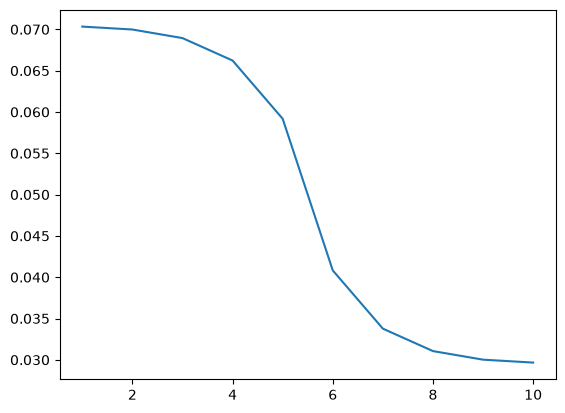

In [3]:

transport_array = np.zeros((example_weighted_dgraph.nodes,example_weighted_dgraph.nodes))
for i in example_weighted_dgraph.edges:
    transport_array[i[1],i[0]] += i[2]
    transport_array[i[0],i[0]] -= i[2]

dt = 0.001
for i in range(30000):
    population_adjusted_transport_array = transport_array @ particle_fractions
    population_adjusted_transport_array = population_adjusted_transport_array*dt
    particle_fractions += population_adjusted_transport_array

x_values = []
y_values = []
for i in range(10,20):
    x_values.append(i-9)
    y_values.append(particle_fractions[i])

plot.plot(x_values,y_values)